Project Title

AstroGuard AI: Advanced Asteroid Hazard Classification & Explainable Risk Screening System

Project Idea

تطوير نظام Machine Learning بيحلل بيانات الكويكبات وبيصنّفها إلى:

Potentially Hazardous Asteroid (PHA)
Non-PHA

النظام هيستخدم orbital characteristics زي a, e, i, q, وmoid، مع مجموعة من الخصائص الأخرى، عشان يتعلم الأنماط المرتبطة بتصنيف PHA.

وهنضيف Explainable AI عشان نقدر نفسّر ليه الموديل صنّف كويكب معيّن على إنه PHA.

Problem Statement — Ready for Your Report
Project Problem Statement

Asteroid classification is an important task in astronomical data analysis, particularly for identifying objects that meet the criteria for potentially hazardous asteroids (PHAs).

This project aims to develop an advanced machine learning system that classifies asteroids into PHA and non-PHA categories using orbital and physical characteristics.

The project addresses the challenges of severe class imbalance, missing astronomical observations, feature redundancy, and the risk of data leakage. Multiple machine learning algorithms will be evaluated using robust validation strategies and class-sensitive evaluation metrics.

The final system will include an explainable prediction pipeline and an interactive web application. The output represents a model-based PHA classification, not a prediction of an actual Earth impact or a scientifically validated impact probability.

3. شكل الـ Advanced Pipeline الل

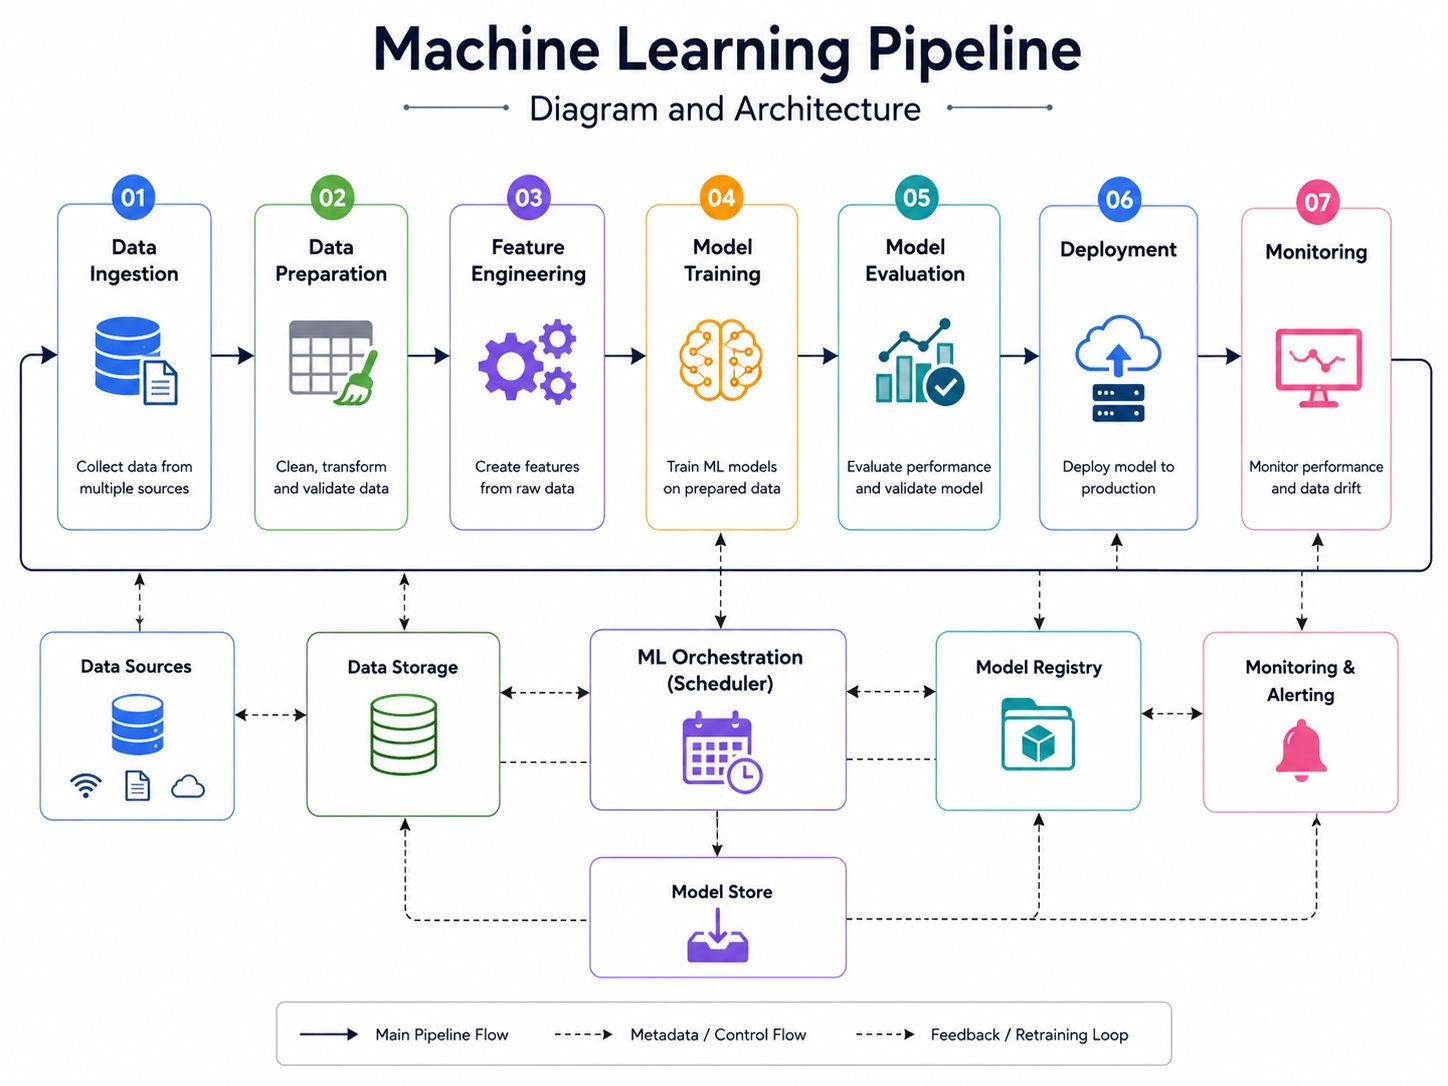

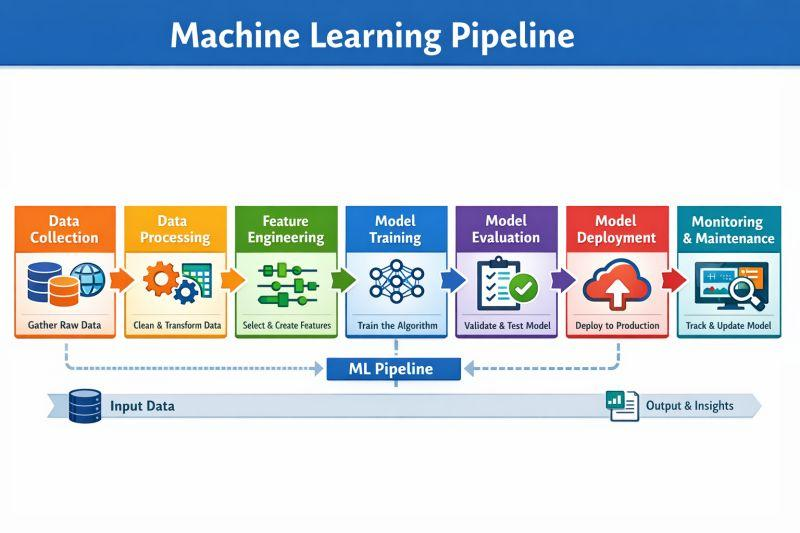

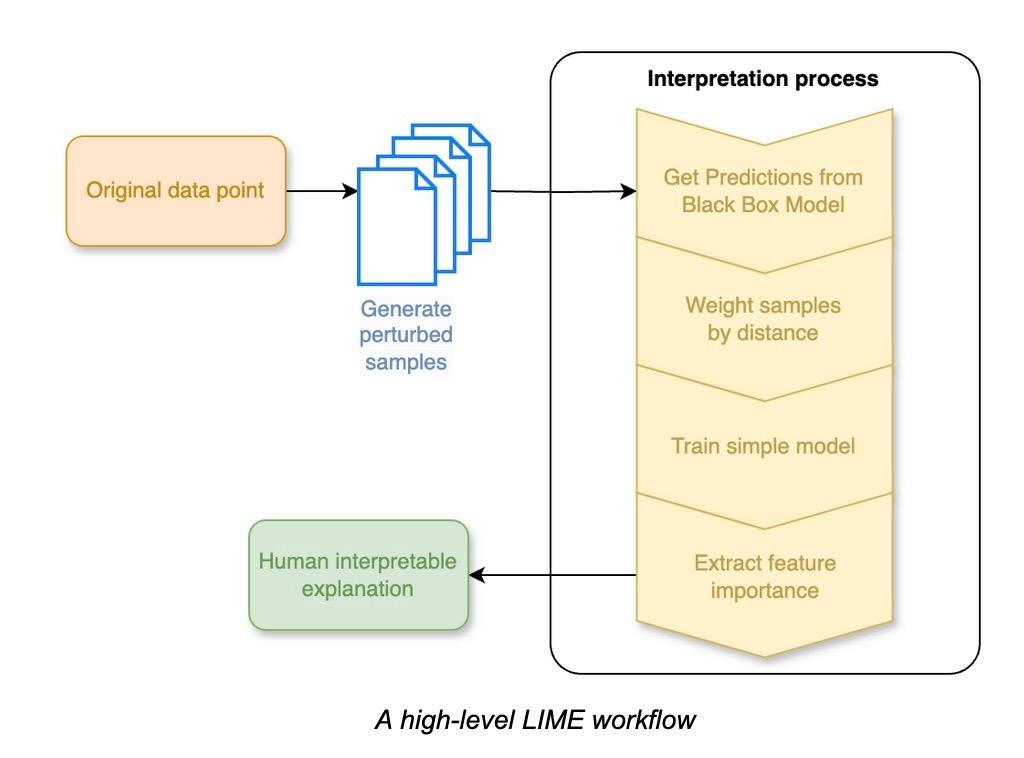

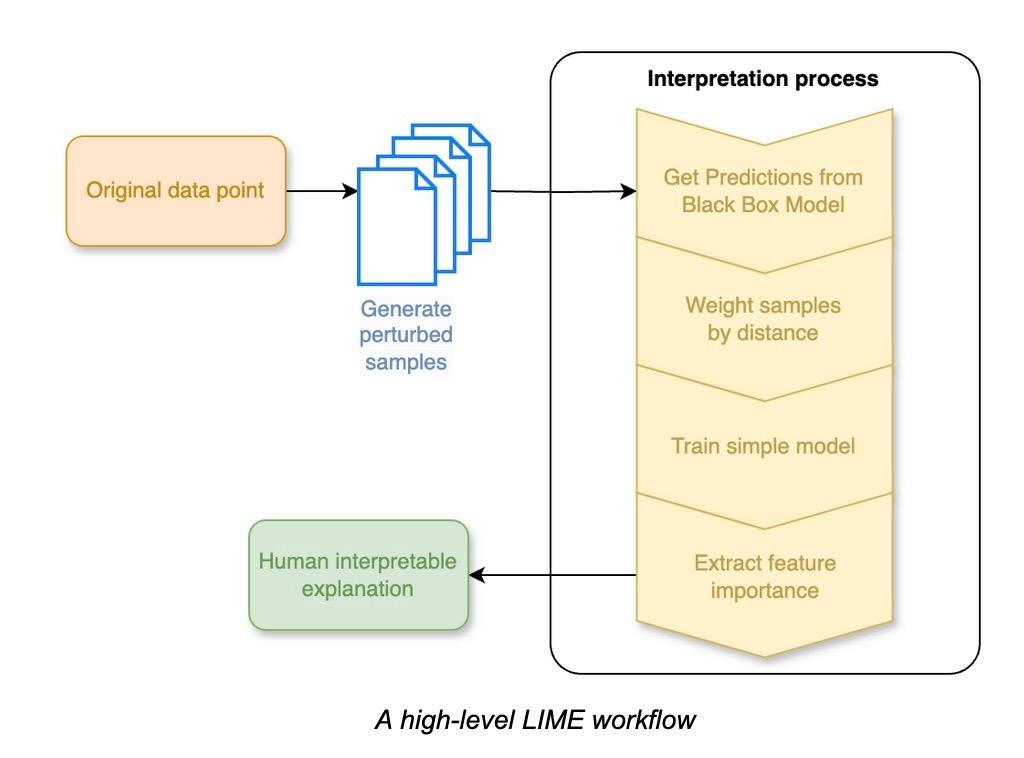

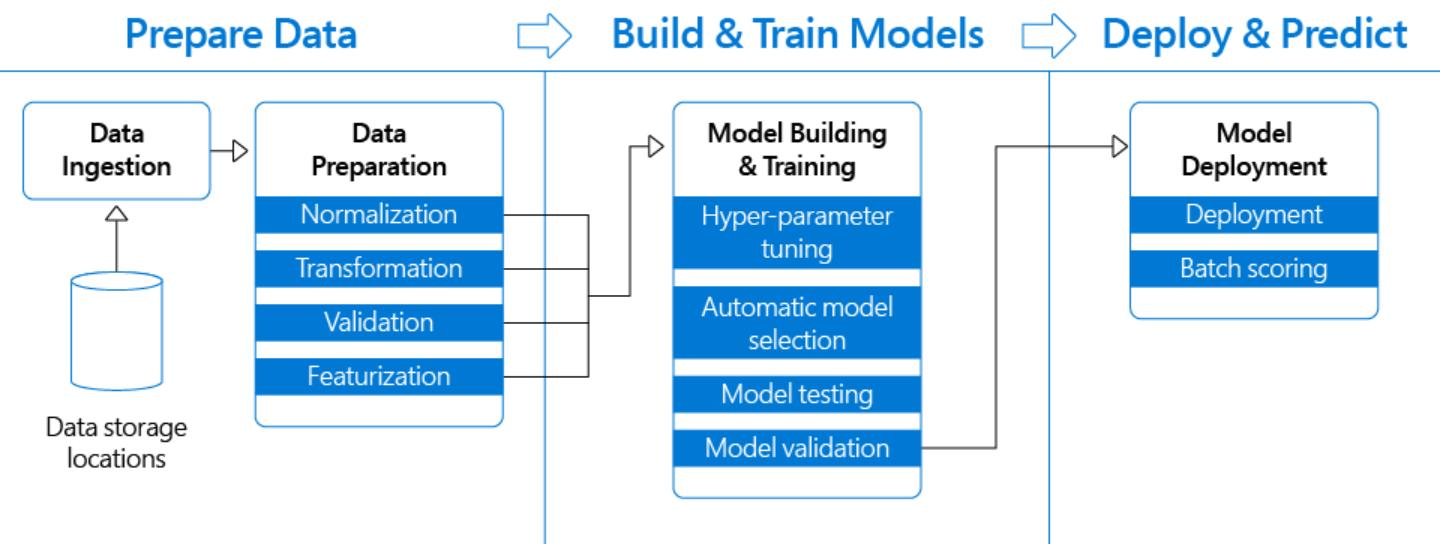

Data Loading & Initial Audit

Install Libraries

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn
!pip install -q imbalanced-learn xgboost lightgbm
!pip install -q shap joblib

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

Load Dataset

In [ ]:
df = pd.read_csv(
    "/content/Asteroid_Updated.csv",
    low_memory=False
)

print("Dataset Shape:", df.shape)

display(df.head())

df.info()

Dataset Shape: (278120, 31)


,name,a,e,i,om,w,q,ad,per_y,data_arc,condition_code,n_obs_used,H,neo,pha,diameter,extent,albedo,rot_per,GM,BV,UB,IR,spec_B,spec_T,G,moid,class,n,per,ma
0,Ceres,2.769165,0.076009,10.594067,80.305532,73.597694,2.558684,2.979647,4.608202,8822,0.0,1002,3.34,N,N,939.4,964.4 x 964.2 x 891.8,0.0900,9.074170,62.6284,0.713,0.426,NaN,C,G,0.12,1.59478,MBA,0.213885,1683.145708,77.372096
1,Pallas,2.772466,0.230337,34.836234,173.080063,310.048857,2.133865,3.411067,4.616444,72318,0.0,8490,4.13,N,N,545,582x556x500,0.1010,7.813200,14.3000,0.635,0.284,NaN,B,B,0.11,1.23324,MBA,0.213503,1686.155999,59.699133
2,Juno,2.669150,0.256942,12.988919,169.852760,248.138626,1.983332,3.354967,4.360814,72684,0.0,7104,5.33,N,N,246.596,NaN,0.2140,7.210000,NaN,0.824,0.433,NaN,Sk,S,0.32,1.03454,MBA,0.226019,1592.787285,34.925016
3,Vesta,2.361418,0.088721,7.141771,103.810804,150.728541,2.151909,2.570926,3.628837,24288,0.0,9325,3.20,N,N,525.4,572.6 x 557.2 x 446.4,0.4228,5.342128,17.8000,0.782,0.492,NaN,V,V,0.32,1.13948,MBA,0.271609,1325.432765,95.861936
4,Astraea,2.574249,0.191095,5.366988,141.576605,358.687607,2.082324,3.066174,4.130323,63507,0.0,2916,6.85,N,N,106.699,NaN,0.2740,16.806000,NaN,0.826,0.411,NaN,S,S,NaN,1.09589,MBA,0.238632,1508.600458,282.366289


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278120 entries, 0 to 278119
Data columns (total 31 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   name            21387 non-null   object 
 1   a               278120 non-null  float64
 2   e               278120 non-null  float64
 3   i               278120 non-null  float64
 4   om              278120 non-null  float64
 5   w               278120 non-null  float64
 6   q               278120 non-null  float64
 7   ad              278120 non-null  float64
 8   per_y           278120 non-null  float64
 9   data_arc        278120 non-null  int64  
 10  condition_code  278119 non-null  float64
 11  n_obs_used      278120 non-null  int64  
 12  H               278120 non-null  float64
 13  neo             278120 non-null  object 
 14  pha             278120 non-null  object 
 15  diameter        104747 non-null  object 
 16  extent          18 non-null      object 
 17  albedo    

Create Initial Data Audit

In [ ]:
audit = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (
        df.isna().mean() * 100
    ).round(2),
    "Unique_Values": df.nunique(dropna=True)
})

audit = audit.sort_values(
    "Missing_Percentage",
    ascending=False
)

display(audit)

audit.to_csv(
    "data_quality_report.csv",
    index=True
)

,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
IR,float64,278119,100.00,1
extent,object,278102,99.99,18
GM,float64,278106,99.99,14
G,float64,278002,99.96,47
spec_T,object,277140,99.65,131
UB,float64,277141,99.65,339
BV,float64,277099,99.63,307
spec_B,object,276556,99.44,31
rot_per,float64,261449,94.01,10435
name,object,256733,92.31,21387


6 — Clean Numeric Columns

In [ ]:
numeric_candidates = [
    "a", "e", "i", "om", "w",
    "q", "ad", "per_y", "data_arc",
    "n_obs_used", "H", "diameter",
    "albedo", "rot_per", "GM",
    "BV", "UB", "IR", "G",
    "moid", "n", "per", "ma"
]

for col in numeric_candidates:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

 7 — Duplicate Audit

In [ ]:
numeric_candidates = [
    "a", "e", "i", "om", "w",
    "q", "ad", "per_y", "data_arc",
    "n_obs_used", "H", "diameter",
    "albedo", "rot_per", "GM",
    "BV", "UB", "IR", "G",
    "moid", "n", "per", "ma"
]

for col in numeric_candidates:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

EDA

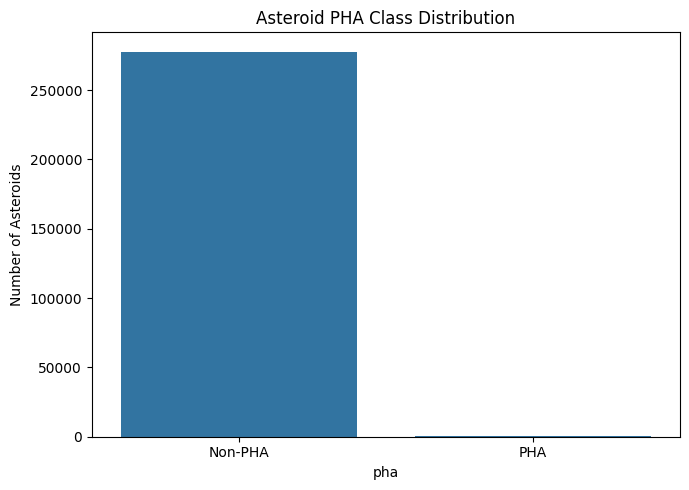

In [ ]:
target_counts = df["pha"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

# Map 'N' to 'Non-PHA' and 'Y' to 'PHA'
labels = ["Non-PHA" if x == 'N' else "PHA" for x in target_counts.index]
plt.xticks(ticks=range(len(target_counts.index)), labels=labels)
plt.title("Asteroid PHA Class Distribution")
plt.ylabel("Number of Asteroids")

plt.tight_layout()
plt.show()

8 Missing value visulaization

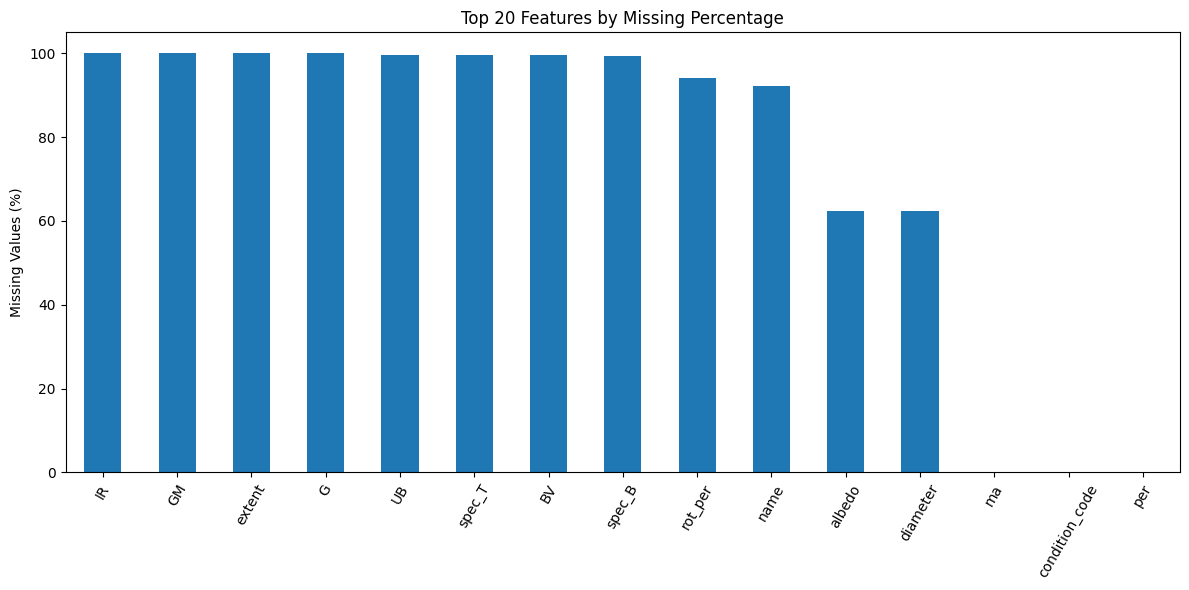

In [ ]:
missing_pct = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_pct = missing_pct[
    missing_pct > 0
]

plt.figure(figsize=(12, 6))

missing_pct.head(20).plot(kind="bar")

plt.title("Top 20 Features by Missing Percentage")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

9 orbital feature distributain

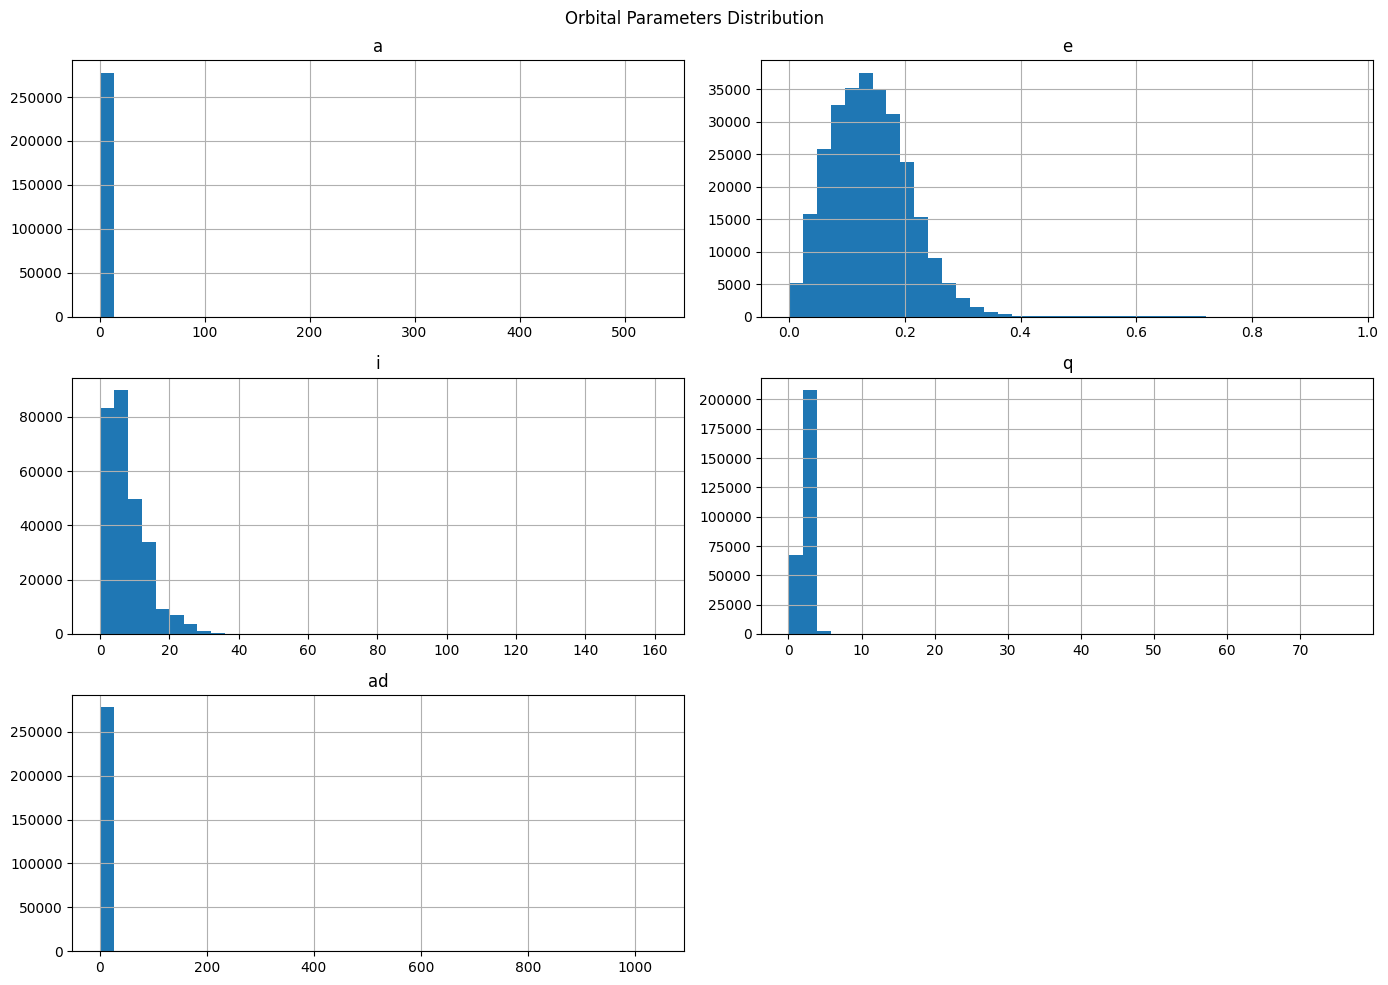

In [ ]:
orbital_features = [
    "a", "e", "i", "q", "ad"
]

df[orbital_features].hist(
    figsize=(14, 10),
    bins=40
)

plt.suptitle("Orbital Parameters Distribution")

plt.tight_layout()
plt.show()

pha vs no pha

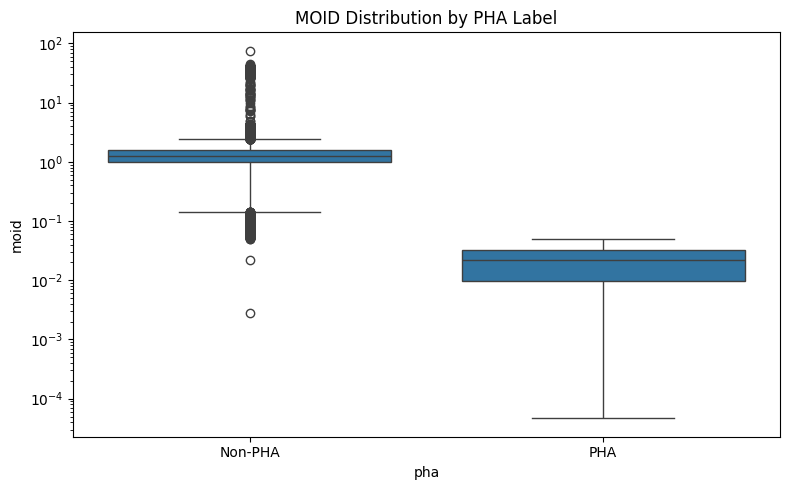

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="pha",
    y="moid"
)

plt.yscale("log")

plt.title("MOID Distribution by PHA Label")
plt.xticks([0, 1], ["Non-PHA", "PHA"])

plt.tight_layout()
plt.show()

Train / Validation / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

TARGET = "pha"

X = df.drop(
    columns=[TARGET, "name"],
    errors="ignore"
)

y = df[TARGET].map({'N': 0, 'Y': 1}) # Convert 'N' to 0 and 'Y' to 1

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain Positive Rate:", y_train.mean())
print("Validation Positive Rate:", y_val.mean())
print("Test Positive Rate:", y_test.mean())

Train: (194684, 29)
Validation: (41718, 29)
Test: (41718, 29)

Train Positive Rate: 0.0011248998376856855
Validation Positive Rate: 0.0011266120139987535
Test Positive Rate: 0.0011266120139987535


Preprocessing Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

# Exclude target-related / identifier columns
excluded_features = [
    "pha",
    "target",
    "name",
    "moid",
    "neo"
]

X_train_model = X_train.drop(
    columns=excluded_features,
    errors="ignore"
)

X_val_model = X_val.drop(
    columns=excluded_features,
    errors="ignore"
)

X_test_model = X_test.drop(
    columns=excluded_features,
    errors="ignore"
)

numeric_features = (
    X_train_model
    .select_dtypes(include=np.number)
    .columns.tolist()
)

categorical_features = (
    X_train_model
    .select_dtypes(exclude=np.number)
    .columns.tolist()
)

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['a', 'e', 'i', 'om', 'w', 'q', 'ad', 'per_y', 'data_arc', 'condition_code', 'n_obs_used', 'H', 'diameter', 'albedo', 'rot_per', 'GM', 'BV', 'UB', 'IR', 'G', 'n', 'per', 'ma']
Categorical: ['extent', 'spec_B', 'spec_T', 'class']


Build Preprocessor

In [ ]:
numeric_pipeline = SkPipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = SkPipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

Feature 1 — Orbital Period Consistency

In [ ]:
def engineer_features(data):
    data = data.copy()

    # Approximate Keplerian orbital period
    if "a" in data.columns:
        data["kepler_period_est"] = (
            data["a"].clip(lower=0) ** 1.5
        )

    # Difference between catalog and estimated period
    if {"per_y", "a"}.issubset(data.columns):
        data["period_consistency"] = (
            data["per_y"] - data["a"].clip(lower=0) ** 1.5
        )

    # Orbital eccentricity squared
    if "e" in data.columns:
        data["eccentricity_squared"] = data["e"] ** 2

    # Orbit radial span
    if {"ad", "q"}.issubset(data.columns):
        data["orbit_radial_span"] = data["ad"] - data["q"]

    # Inclination in radians
    if "i" in data.columns:
        data["inclination_rad"] = np.deg2rad(data["i"])

    return data

outlier analyssis treatment

In [ ]:
# Domain validation examples
if "e" in df.columns:
    print(
        "Eccentricity outside [0, 1):",
        ((df["e"] < 0) | (df["e"] >= 1)).sum()
    )

if "a" in df.columns:
    print(
        "Non-positive semi-major axis:",
        (df["a"] <= 0).sum()
    )

if "diameter" in df.columns:
    print(
        "Non-positive diameter:",
        (df["diameter"] <= 0).sum()
    )

Eccentricity outside [0, 1): 0
Non-positive semi-major axis: 0
Non-positive diameter: 0


Build Initial Model Pipelines

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from imblearn.pipeline import Pipeline as ImbPipeline

models = {
    "Dummy": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    )
}

Train & Evaluate

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

results = []
trained_models = {}

for model_name, model in models.items():

    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_train_model,
        y_train
    )

    y_pred = pipeline.predict(X_val_model)

    y_prob = pipeline.predict_proba(
        X_val_model
    )[:, 1]

    results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_val, y_pred
        ),

        "Precision": precision_score(
            y_val, y_pred, zero_division=0
        ),

        "Recall": recall_score(
            y_val, y_pred, zero_division=0
        ),

        "F1": f1_score(
            y_val, y_pred, zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_val, y_prob
        ),

        "PR_AUC": average_precision_score(
            y_val, y_prob
        )
    })

    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "PR_AUC",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,Random Forest,0.998562,0.431579,0.872340,0.577465,0.999461,0.586326
1,Logistic Regression,0.997124,0.278788,0.978723,0.433962,0.999184,0.452660
0,Dummy,0.998873,0.000000,0.000000,0.000000,0.500000,0.001127


model optimization

1.cross validation

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

2.hyperparameter optimization

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),

    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])

param_dist = {
    "model__n_estimators": [200, 300, 500],

    "model__max_depth": [
        None, 10, 20, 30
    ],

    "model__min_samples_leaf": [
        1, 2, 5, 10
    ],

    "model__max_features": [
        "sqrt", 0.5, 0.8
    ]
}

search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
)

search.fit(
    X_train_model,
    y_train
)

print("Best Parameters:")
print(search.best_params_)

print("Best CV PR-AUC:")
print(search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


3.threeshold optimization

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    fbeta_score
)

best_model = search.best_estimator_

val_prob = best_model.predict_proba(
    X_val_model
)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_val,
    val_prob
)

f2_scores = (
    5 * precision[:-1] * recall[:-1]
) / (
    4 * precision[:-1] + recall[:-1] + 1e-12
)

best_idx = np.argmax(f2_scores)

best_threshold = thresholds[best_idx]

print("Selected Threshold:", best_threshold)
print("Validation F2:", f2_scores[best_idx])

Final Evaluation

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

test_prob = best_model.predict_proba(
    X_test_model
)[:, 1]

test_pred = (
    test_prob >= best_threshold
).astype(int)

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "Non-PHA",
            "PHA"
        ],
        zero_division=0
    )
)

print(
    "Test PR-AUC:",
    average_precision_score(
        y_test,
        test_prob
    )
)

print(
    "Test ROC-AUC:",
    roc_auc_score(
        y_test,
        test_prob
    )
)

cm = confusion_matrix(
    y_test,
    test_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-PHA", "PHA"]
).plot()

plt.title("Final Test Confusion Matrix")
plt.show()

Explainable AI (SHAP)

مش كفاية نقول إن الـ Model حقق PR-AUC مرتفع. لازم نفهم إيه الخصائص اللي أثّرت على قراراته.

هنستخدم SHAP عشان نجاوب على سؤالين:

Global Explainability: إيه أهم Features على مستوى الـ Dataset؟
Local Explainability: ليه الـ Model صنّف Asteroid معيّن على إنه PHA؟

In [ ]:
import shap

# Transform a manageable sample
X_shap = X_test_model.sample(
    n=min(500, len(X_test_model)),
    random_state=42
)

# Explain the fitted model
# For tree-based models, use TreeExplainer when supported.
# Start with a manageable sample to control memory.

model = best_model.named_steps["model"]

X_shap_transformed = (
    best_model.named_steps["preprocessor"]
    .transform(X_shap)
)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_shap_transformed
)

shap.summary_plot(
    shap_values,
    X_shap_transformed
)

Save the Complete Model

In [ ]:
import joblib

artifact = {
    "model": best_model,
    "threshold": float(best_threshold),

    "target": "pha",

    "excluded_features": [
        "pha",
        "target",
        "name",
        "moid",
        "neo"
    ]
}

joblib.dump(
    artifact,
    "astroguard_model.joblib"
)

build fast api backend  
app.py

model class.
model score
applied thresshold
model version

In [ ]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import pandas as pd
import joblib

app = FastAPI(
    title="AstroGuard AI API",
    version="1.0.0"
)

artifact = joblib.load(
    "astroguard_model.joblib"
)

model = artifact["model"]
threshold = artifact["threshold"]


class AsteroidInput(BaseModel):
    a: float
    e: float
    i: float
    q: float
    ad: float
    per_y: float
    data_arc: float
    n_obs_used: int
    H: float


@app.get("/")
def home():
    return {
        "message": "AstroGuard AI API is running"
    }


@app.post("/predict")
def predict(data: AsteroidInput):

    try:
        input_df = pd.DataFrame(
            [data.model_dump()]
        )

        input_df = engineer_features(
            input_df
        )

        probability = float(
            model.predict_proba(
                input_df
            )[:, 1][0]
        )

        prediction = int(
            probability >= threshold
        )

        return {
            "prediction": prediction,
            "classification": (
                "PHA" if prediction == 1
                else "Non-PHA"
            ),
            "model_score": probability,
            "threshold": threshold,
            "disclaimer": (
                "Model-based PHA classification; "
                "not an impact probability."
            )
        }

    except Exception as e:
        raise HTTPException(
            status_code=400,
            detail=str(e)
        )

stramlit ui

In [ ]:
import streamlit as st
import requests

st.set_page_config(
    page_title="AstroGuard AI",
    page_icon="🌌",
    layout="wide"
)

st.title("🌌 AstroGuard AI")
st.subheader(
    "Asteroid Hazard Classification System"
)

st.warning(
    "This system predicts catalog-based PHA "
    "classification. It does not calculate "
    "actual Earth impact probability."
)

with st.form("asteroid_form"):

    a = st.number_input(
        "Semi-major Axis (AU)",
        min_value=0.01,
        value=2.5
    )

    e = st.number_input(
        "Eccentricity",
        min_value=0.0,
        max_value=0.99,
        value=0.2
    )

    i = st.number_input(
        "Inclination (degrees)",
        min_value=0.0,
        value=10.0
    )

    q = st.number_input(
        "Perihelion Distance (AU)",
        min_value=0.01,
        value=1.8
    )

    ad = st.number_input(
        "Aphelion Distance (AU)",
        min_value=0.01,
        value=3.0
    )

    per_y = st.number_input(
        "Orbital Period (years)",
        min_value=0.01,
        value=4.0
    )

    data_arc = st.number_input(
        "Observation Arc (days)",
        min_value=0.0,
        value=1000.0
    )

    n_obs_used = st.number_input(
        "Number of Observations",
        min_value=1,
        value=100
    )

    H = st.number_input(
        "Absolute Magnitude",
        value=18.0
    )

    submitted = st.form_submit_button(
        "Analyze Asteroid"
    )

if submitted:

    payload = {
        "a": a,
        "e": e,
        "i": i,
        "q": q,
        "ad": ad,
        "per_y": per_y,
        "data_arc": data_arc,
        "n_obs_used": n_obs_used,
        "H": H
    }

    response = requests.post(
        "http://127.0.0.1:8000/predict",
        json=payload
    )

    if response.status_code == 200:

        result = response.json()

        st.metric(
            "Model Score",
            f"{result['model_score']:.2%}"
        )

        st.success(
            result["classification"]
        )

        st.caption(
            "This result is a model classification, "
            "not a validated impact probability."
        )

    else:
        st.error(
            "Prediction failed. Check API and inputs."
        )

User

  |

  v

Streamlit Frontend

  |
  
  v

FastAPI Backend

  |

  v

Saved Preprocessing + ML Pipeline

  |
  
  v

Prediction + Model Score

  |
  
  v

Explainability + Disclaimer

أهم 3 تجارب علمية في المشروع
Experiment 1 — Does MOID Dominate the Model?

هنقارن:

Orbital-Only Model
Orbital + MOID Model
Orbital + NEO Model
Orbital + MOID + NEO Model

الهدف مش إننا نختار أعلى نتيجة وخلاص، لكن نفهم هل الـ Model بيعتمد على Feature قريبة من تعريف الـ Target، وهل الأداء يظل جيدًا عند استبعادها.

Experiment 2 — Imbalance Handling Comparison

هنقارن:

No Resampling
Class Weights
Random Undersampling
SMOTE على Training Folds مناسبة

هنستخدم نفس الـ Split والـ Evaluation Metrics، ونوثّق تأثير كل طريقة على Precision وRecall وPR-AUC.

Experiment 3 — Feature Engineering Ablation

هنقارن أداء الموديل باستخدام:

Original Features
Original + Engineered Features
Selected Features Only

وده هيساعدنا نعرف إذا كانت الـ Feature Engineering أضافت قيمة فعلية ولا زوّدت التعقيد فقط.

dataset profile dashboard

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "/content/Asteroid_Updated.csv",
    low_memory=False
)

profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique": df.nunique()
})

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Memory MB:", round(
    df.memory_usage(deep=True).sum() / 1e6, 2
))

display(profile.sort_values(
    "missing_pct", ascending=False
))

Visualization 1 — Missingness by Feature

In [ ]:
missing_pct = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(14, 7))

sns.barplot(
    x=missing_pct.index,
    y=missing_pct.values
)

plt.xticks(rotation=75)
plt.ylabel("Missing Percentage (%)")
plt.title("Missingness Across Asteroid Features")

plt.tight_layout()
plt.show()

EDA Module 2 — Target Distribution & Class Imbalance

In [ ]:
df["pha"] = (
    df["pha"].astype("string").str.strip().str.upper()
)

labeled = df[df["pha"].isin(["Y", "N"])].copy()

counts = labeled["pha"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    x=counts.index,
    y=counts.values,
    ax=ax[0]
)

ax[0].set_title("PHA vs Non-PHA Counts")
ax[0].set_ylabel("Number of Asteroids")

sns.barplot(
    x=counts.index,
    y=counts.values / counts.sum() * 100,
    ax=ax[1]
)

ax[1].set_title("PHA vs Non-PHA Percentage")
ax[1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

EDA Module 3 — Univariate Analysis

In [ ]:
features = [
    "a", "e", "i", "q",
    "ad", "per_y", "H",
    "data_arc", "n_obs_used",
    "diameter", "albedo", "moid"
]

features = [
    c for c in features if c in labeled.columns
]

for col in features:

    values = pd.to_numeric(
        labeled[col],
        errors="coerce"
    ).dropna()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(
        values,
        bins=50,
        kde=True,
        ax=ax[0]
    )

    ax[0].set_title(f"{col} Distribution")

    sns.boxplot(
        x=values,
        ax=ax[1]
    )

    ax[1].set_title(f"{col} Outlier Inspection")

    plt.tight_layout()
    plt.show()

EDA Module 4 — Log Transformation Analysis

In [ ]:
from scipy.stats import skew

log_candidates = [
    "data_arc",
    "n_obs_used",
    "diameter",
    "albedo"
]

for col in log_candidates:

    x = pd.to_numeric(
        labeled[col],
        errors="coerce"
    )

    x = x[
        np.isfinite(x) & (x >= 0)
    ].dropna()

    if len(x) == 0:
        continue

    log_x = np.log1p(x)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(x, bins=50, ax=ax[0])
    ax[0].set_title(f"Original {col}")

    sns.histplot(log_x, bins=50, ax=ax[1])
    ax[1].set_title(f"log1p({col})")

    plt.tight_layout()
    plt.show()

    print(
        col,
        "Original Skew:", round(skew(x), 3),
        "Log Skew:", round(skew(log_x), 3)
    )

EDA Module 5 — Correlation Heatmap

In [ ]:
corr_features = [
    "a", "e", "i", "om", "w",
    "q", "ad", "per_y", "H",
    "data_arc", "n_obs_used",
    "diameter", "albedo", "moid"
]

corr_features = [
    c for c in corr_features
    if c in labeled.columns
]

corr_df = labeled[corr_features].apply(
    pd.to_numeric,
    errors="coerce"
)

corr = corr_df.corr(
    method="spearman"
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Spearman Correlation Heatmap")

plt.tight_layout()
plt.show()

EDA Module 6 — Bivariate Analysis: PHA vs Orbital Features

In [ ]:
plot_features = ["a", "e", "i", "q", "H", "moid"]

for col in plot_features:

    if col not in labeled.columns:
        continue

    temp = labeled[["pha", col]].copy()

    temp[col] = pd.to_numeric(
        temp[col],
        errors="coerce"
    )

    temp = temp.dropna()

    # Sampling is for visualization only
    temp = temp.groupby(
        "pha",
        group_keys=False
    ).apply(
        lambda x: x.sample(
            min(len(x), 5000),
            random_state=42
        )
    )

    plt.figure(figsize=(8, 5))

    sns.violinplot(
        data=temp,
        x="pha",
        y=col,
        hue="pha",
        legend=False,
        inner="quartile"
    )

    plt.title(f"{col} Distribution by PHA Label")

    plt.tight_layout()
    plt.show()

Part 5 — Euclidean Distance vs Mahalanobis Distance

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis

distance_features = [
    "a", "e", "i", "q", "ad"
]

X_dist = labeled[distance_features].copy()

X_dist = X_dist.replace(
    [np.inf, -np.inf],
    np.nan
)

imputer = SimpleImputer(strategy="median")

X_imp = imputer.fit_transform(X_dist)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imp)

# Use a manageable sample for covariance estimation
rng = np.random.default_rng(42)

idx = rng.choice(
    len(X_scaled),
    size=min(20000, len(X_scaled)),
    replace=False
)

X_sample = X_scaled[idx]

cov = np.cov(
    X_sample,
    rowvar=False
)

# Pseudo-inverse helps with near-singular covariance matrices
cov_inv = np.linalg.pinv(cov)

mean_vec = X_sample.mean(axis=0)

md = np.array([
    mahalanobis(x, mean_vec, cov_inv)
    for x in X_sample
])

plt.figure(figsize=(9, 5))

sns.histplot(md, bins=60, kde=True)

plt.title("Mahalanobis Distance Distribution")
plt.xlabel("Mahalanobis Distance")

plt.tight_layout()
plt.show()

Part 6 — K-Fold, Overfitting & Leakage: الـ Correct Advanced Setup    
  Full Labeled Dataset
        |
        v
Stratified Train / Validation / Test Split
        |
        +----------------------+
        |                      |
        v                      v
   Train Set               Test Set
        |
        v
  Stratified 5-Fold CV
        |
        v
Imputation + Scaling + Feature Selection
        |
        v
  Model Training
        |
        v
  Validation Metrics
        |
        v
Hyperparameter Optimization
        |
        v
Final Model Selection
        |
        v
One-Time Test Evaluation

Part 7 — Probability Calibration

دي نقطة مختلفة عن Threshold Optimization.

Model Score مش بالضرورة Probability معايرة.

يعني لو موديل رجّع Score = 0.80، ده مش معناه تلقائيًا إن 80% من الحالات اللي ليها نفس الـ Score هتكون PHA.

هنستخدم Calibration Analysis عشان نختبر مدى توافق الـ Predicted Probabilities مع التكرارات الفعلية.

ممكن نجرّب:

Sigmoid Calibration.
Isotonic Calibration.

لكن الـ Calibration لازم يتعمل من غير ما نستخدم Test Labels في الـ Fit.

والـ Reliability Diagram هيساعدنا نشوف هل الـ Scores متوافقة مع الـ Observed Frequencies.

Part 8 — LightGBM + SMOTE + Calibration

In [ ]:
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

lgbm_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),

    ("smote", SMOTE(
        sampling_strategy=0.10,
        k_neighbors=3,
        random_state=42
    )),

    ("model", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight=None,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

2. PCA

هنستخدم PCA أساسًا كـ Exploratory Visualization، ونختبر تأثيره على الموديلات اللي تستفيد منه.

لكن PCA مش بديل عن Feature Selection، ومش مضمون يحسّن Tree-Based Models.

3. أهم Diagram في المشروع: Leakage-Safe ML Pipeline

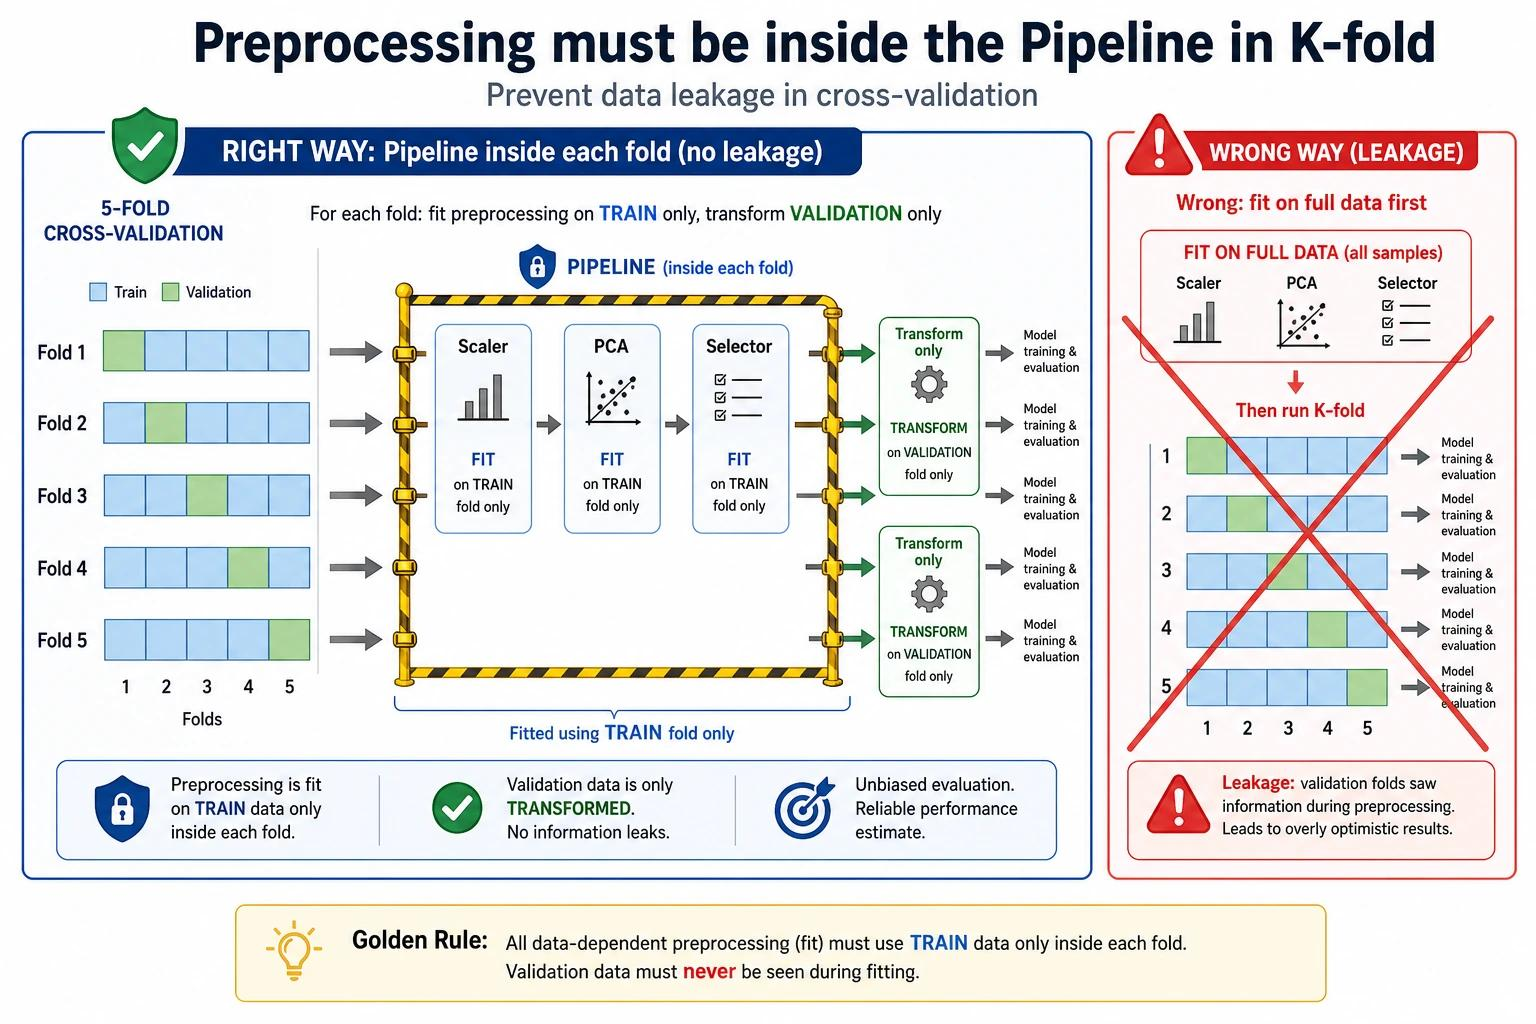

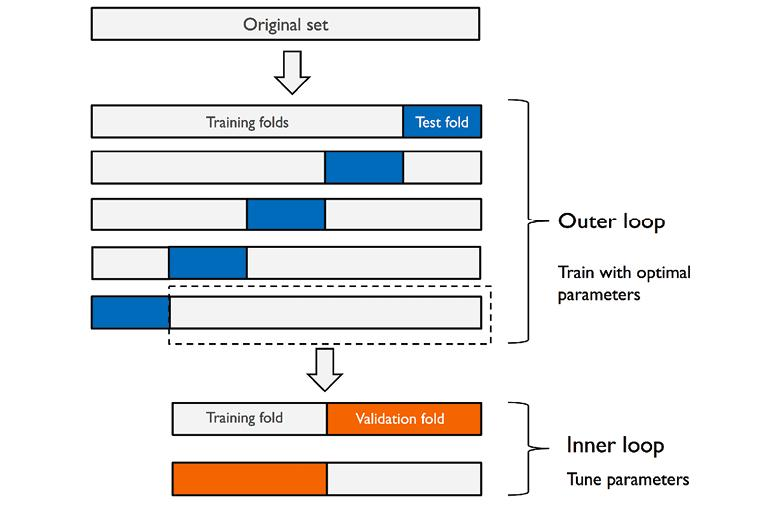

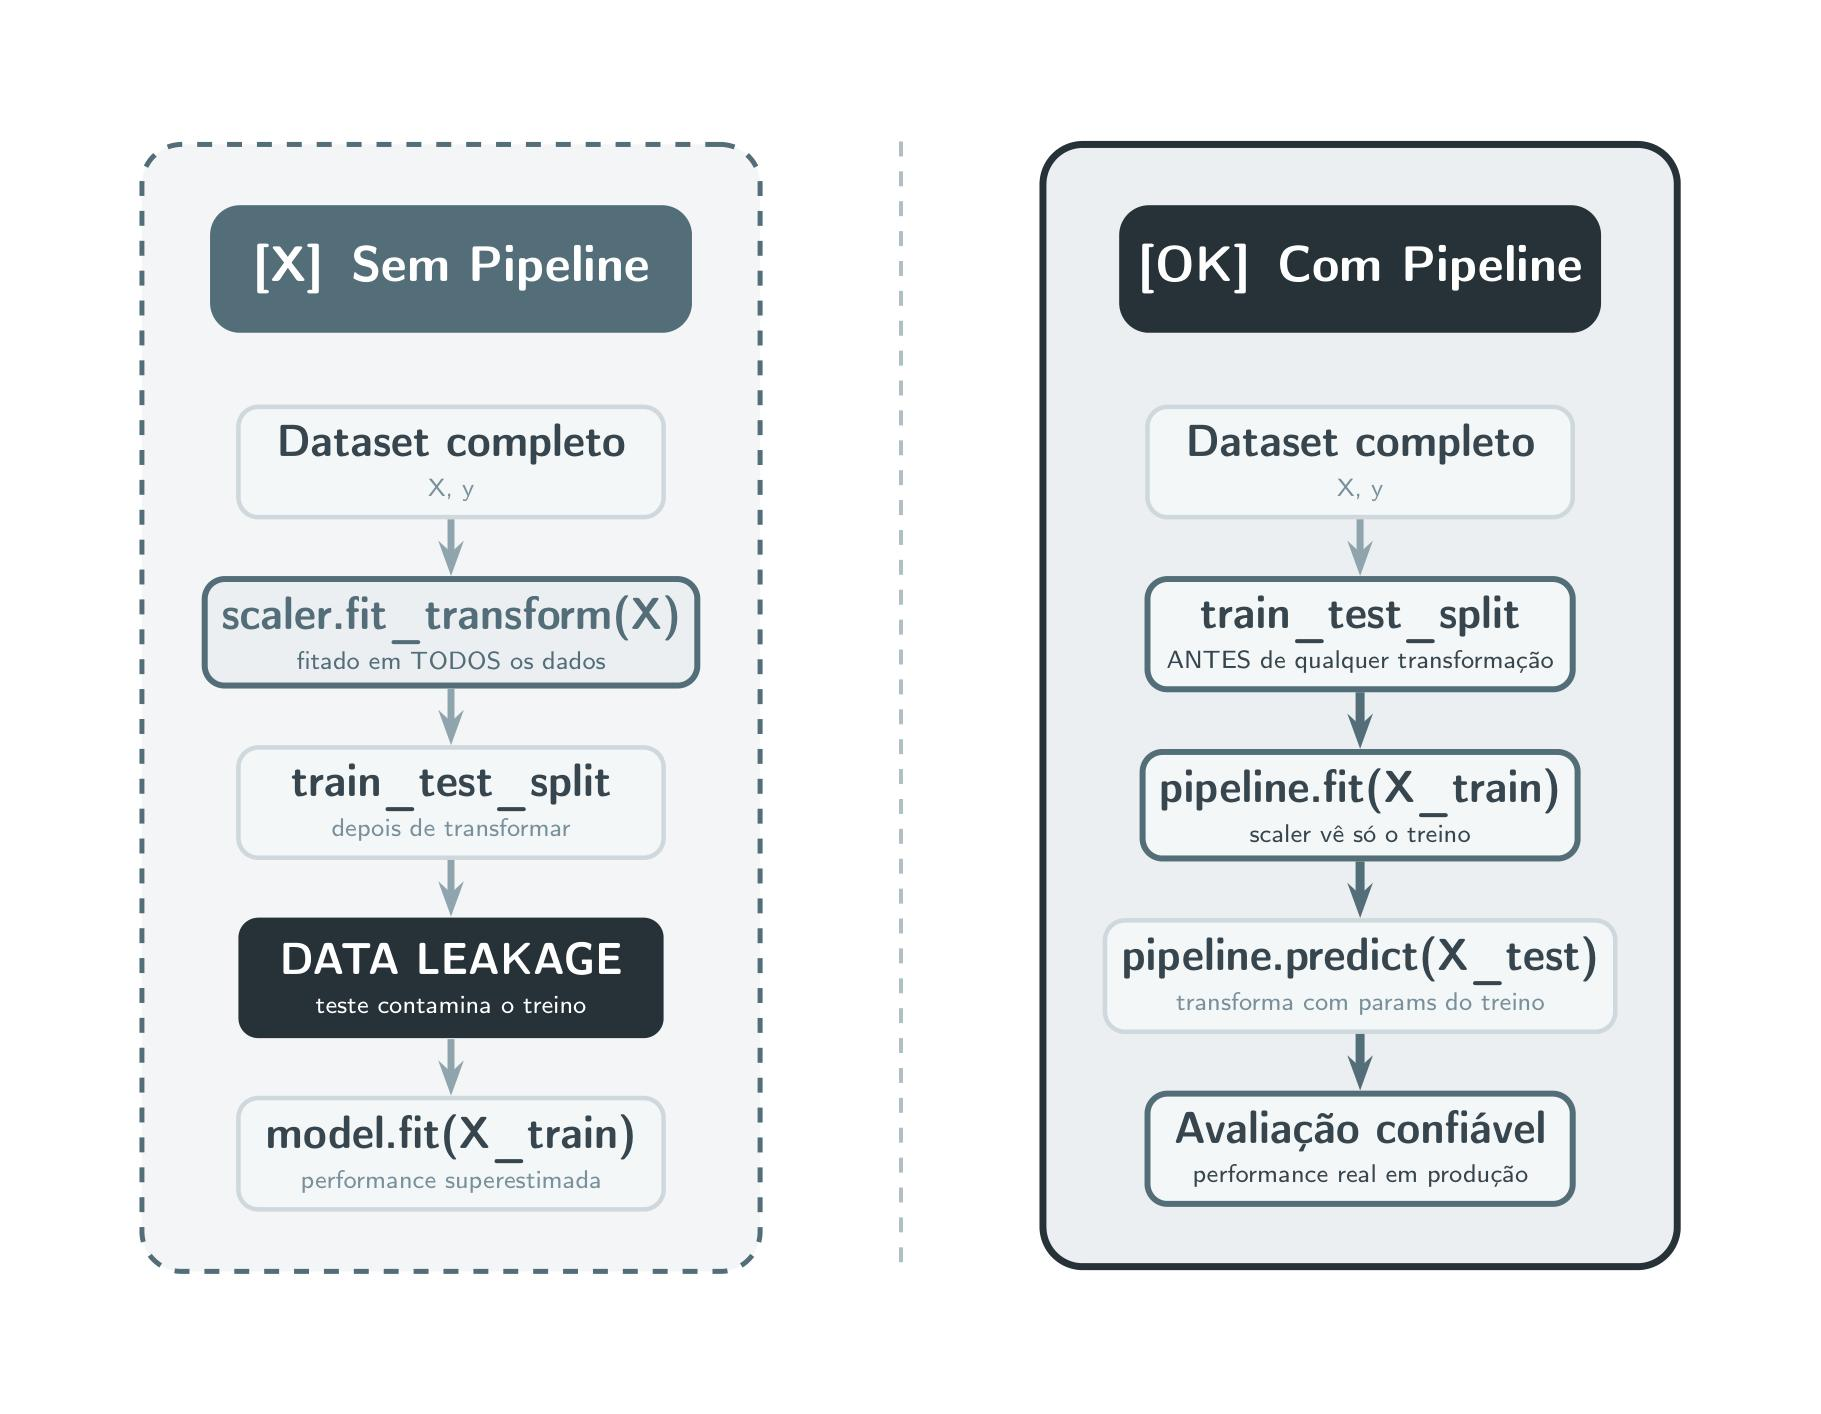